**Aula 1 NLW Rocketseat**

In [1]:
# Instala PyTorch e Torchvision no kernel atual
%pip install torch torchvision


Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5ReLU(nn.Module):
    def __init__(self):
        super(LeNet5ReLU, self).__init__()
        
        # Layer definitions
        # Input: 1 channel (Grayscale), Output: 6 channels, Kernel: 5x5
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1)
        
        # Pooling Layer
        # Keeping AvgPool as per the original design, although MaxPool is common with ReLU
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Input: 6 channels, Output: 16 channels, Kernel: 5x5
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        
        # Fully Connected (Dense) Layers
        # The flattened input size is 16 * 5 * 5 = 400
        self.fc1 = nn.Linear(in_features=16 * 5 * 5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)

    def forward(self, x):
        # Activation Change: Tanh -> ReLU
        # Layer 1: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        
        # Layer 2: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten: Prepare for Dense layers
        x = x.view(-1, 16 * 5 * 5)
        
        # Layer 3: FC -> ReLU
        x = F.relu(self.fc1(x))
        
        # Layer 4: FC -> ReLU
        x = F.relu(self.fc2(x))
        
        # Output Layer
        # No activation here; CrossEntropyLoss includes the Softmax operation
        x = self.fc3(x)
        
        return x

# Instantiation for verification
model = LeNet5ReLU()
print(model)

LeNet5ReLU(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


--- Analyzing conv1 ---
Tensor Shape: torch.Size([6, 1, 5, 5])
Statistics: Mean=0.0115, Std=0.1159, Min=-0.1996, Max=0.1975


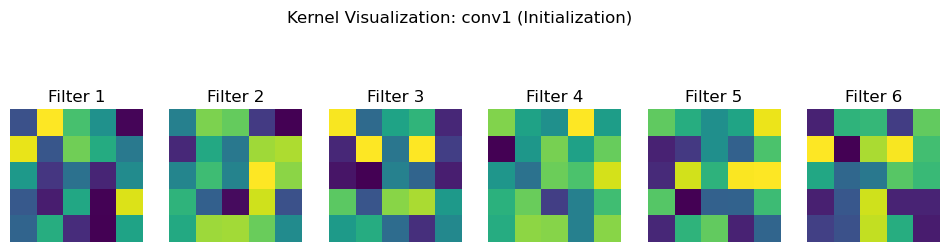


--- conv2 Status ---
Shape: torch.Size([16, 6, 5, 5])
Note: Filters currently look like random noise because the training hasn't refined the features yet.


In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'


import matplotlib.pyplot as plt
import numpy as np

# Ensure the 'model' has been instantiated in a previous cell
# model = LeNet5() 

def visualize_filters(layer, layer_name):
    """
    Extracts and plots the weights of a convolutional layer.
    Weights shape: [out_channels, in_channels, kernel_h, kernel_w]
    """
    # Use .detach().cpu() to ensure compatibility with GPU-trained models
    weights = layer.weight.data.detach().cpu()
    
    num_filters = weights.shape[0]
    kernel_size = weights.shape[2]
    
    print(f"--- Analyzing {layer_name} ---")
    print(f"Tensor Shape: {weights.shape}")
    print(f"Statistics: Mean={weights.mean():.4f}, Std={weights.std():.4f}, Min={weights.min():.4f}, Max={weights.max():.4f}")
    
    # Plot configuration
    fig, axes = plt.subplots(1, num_filters, figsize=(num_filters * 2, 3))
    
    for i in range(num_filters):
        # Extract the i-th filter and the first input channel (index 0)
        # In conv1, there is only 1 channel (grayscale), so index 0 is always used
        kernel_img = weights[i, 0].numpy()
        
        ax = axes[i] if num_filters > 1 else axes
        # 'viridis' or 'gray' are excellent for visualizing intensity/weights
        ax.imshow(kernel_img, cmap='viridis') 
        ax.axis('off')
        ax.set_title(f'Filter {i+1}')
    
    plt.suptitle(f"Kernel Visualization: {layer_name} (Initialization)", y=1.05)
    plt.show()

# Visualizing the first convolutional layer (conv1)
visualize_filters(model.conv1, "conv1")

# Visualizing statistics for the second layer (conv2) without plotting 
# (conv2 has 16 filters across 6 channels, which is harder to visualize in 2D)
print("\n--- conv2 Status ---")
print(f"Shape: {model.conv2.weight.data.shape}")
print("Note: Filters currently look like random noise because the training hasn't refined the features yet.")

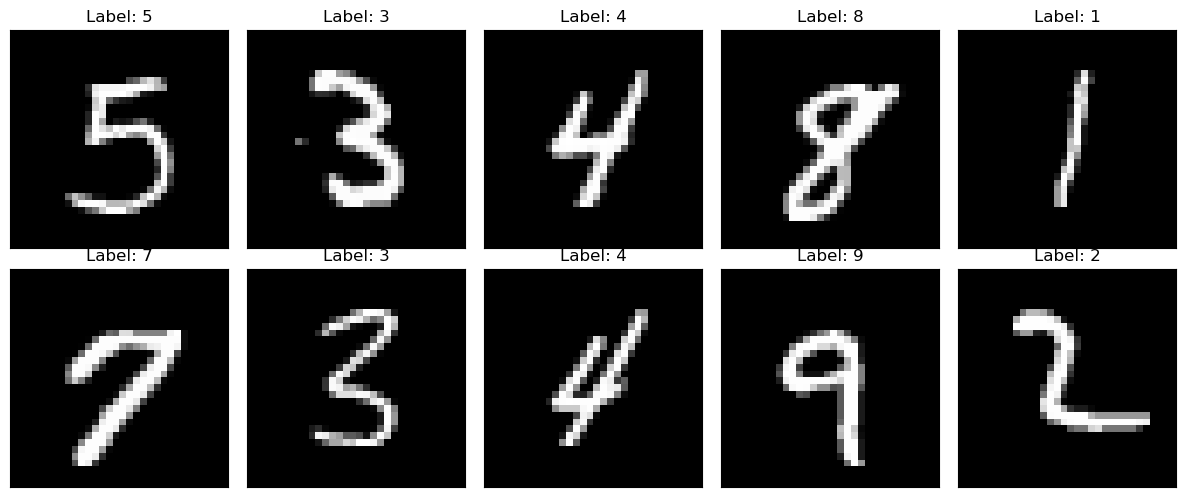

Batch Dimension: torch.Size([64, 1, 32, 32])
Single Image Dimension: torch.Size([1, 32, 32])


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. Transformation Definitions
# MNIST images are 28x28, but the classic LeNet-5 expects 32x32.
# We apply transforms.Pad(2) to add a 2-pixel border on each side (28+2+2 = 32).
data_transform = transforms.Compose([
    transforms.Pad(padding=2), 
    transforms.ToTensor(),
    # Standard normalization for MNIST: mean 0.1307 and std deviation 0.3081
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2. Download and Load Dataset
# download=True will fetch the files to the './data' directory if not present
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=data_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=data_transform)

# 3. Create DataLoaders
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# 4. Visualize Sample Data
# Extract a batch of images
data_iterator = iter(train_loader)
images, labels = next(data_iterator)

# Plot configuration
fig = plt.figure(figsize=(12, 5))
num_images = 10  # Number of samples to display

for i in range(num_images):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    
    # Image processing for display:
    img = images[i]
    
    # Denormalize for correct visualization: z = (x - mean) / std => x = z * std + mean
    img = img * 0.3081 + 0.1307
    
    # Convert tensor to numpy and adjust dimensions: (C, H, W) -> (H, W, C)
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)), cmap='gray')
    
    ax.set_title(f"Label: {labels[i].item()}")

plt.tight_layout()
plt.show()

# Dimension verification
print(f"Batch Dimension: {images.shape}")
print(f"Single Image Dimension: {images[0].shape}")

# Training the Network
Setting up the training loop with CrossEntropyLoss and Adam optimizer. We'll use a larger batch size for efficient training

In [5]:
import torch.optim as optim
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Check if the gpu exists and use it, otherwise fallback to cpu
print(f"Training on device: {device}")

# 2. Initialize the Model
# Instantiate the modified LeNet5 (with ReLU) and move it to the device
model = LeNet5ReLU().to(device)

# Hyperparameters
learning_rate = 0.001 # The smallest learning rate is often a good starting point for Adam
batch_size = 64 # How many samples (images) to process before updating the model's weights
num_epochs = 5 # Number of times to loop through the entire training dataset

# Update the DataLoaders with the largest batch size (if needed)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# 3. Define Loss Function and Optimizer
# CrossEntropyLoss combines LogSoftmax and NLLLoss in one single class
# Compares the raw output scores (logits) from the model with the true class labels and computes the loss
criterion = nn.CrossEntropyLoss() 

# Adam optimizer usually converges faster than standard SGD
# Corrects the optimizer definition to use the learning_rate variable
optimizer = optim.Adam(model.parameters(), lr=learning_rate) 

# 4. Training Loop
train_losses = []
test_accuracies = []

print("\nStarting training...")
start_time = time.time()

for epoch in range(num_epochs):
    # Set the model to training mode (enables dropout/batchnorm behavior if present)
    model.train() 
    running_loss = 0.0
    
    # --- Loop de Treino ---
    for i, (images, labels) in enumerate(train_loader): #Loading 64 images and labels in each iteration
        # Move tensors to the configured device
        images, labels = images.to(device), labels.to(device)
        
        # Zero the parameter gradients to prevent accumulation

        optimizer.zero_grad()
        
        # Forward pass: the results from the model (logits for each class)
        outputs = model(images)
        
        # Calculate the loss
        loss = criterion(outputs, labels) # Response x Correct class labels
        
        # Backward pass: Fixing the errors
        loss.backward()
        
        # Update weights: update our filters 
        optimizer.step()
        
        running_loss += loss.item()
    
    # Calculate the average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # Validation/Test Loop 
    model.eval()  # Set the model to evaluation mode (disables dropout/batchnorm behavior)
    correct = 0
    total = 0
    
    # Disable gradient calculation for validation/testing to save memory and computations
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Get the predicted class with the highest score
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Accuracy: {accuracy:.2f}%")

end_time = time.time()
print(f"\nTraining finished in {(end_time - start_time):.2f} seconds.")

torch.save(model.state_dict(), 'lenet5_mnist.pth')
print("Model saved as 'lenet5_mnist.pth'")


Training on device: cpu

Starting training...
Epoch [1/5] Loss: 0.2770 | Accuracy: 97.29%
Epoch [2/5] Loss: 0.0829 | Accuracy: 98.08%
Epoch [3/5] Loss: 0.0581 | Accuracy: 98.47%
Epoch [4/5] Loss: 0.0446 | Accuracy: 98.63%
Epoch [5/5] Loss: 0.0385 | Accuracy: 98.51%

Training finished in 260.50 seconds.
Model saved as 'lenet5_mnist.pth'


# Evaluating the performance 

In [6]:
# Set the model to evaluation mode
# This is crucial as it disables dropout and changes batchnorm behavior
model.eval()

# track test loss
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

print("Starting evaluation on the test set...")

# Turn off gradients for validation, saves memory and computations
with torch.no_grad():
    for data, target in test_loader:
        # Move tensors to the configured device
        data, target = data.to(device), target.to(device)
        
        # Forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        
        # Calculate the loss
        loss = criterion(output, target)
        
        # update test loss 
        test_loss += loss.item()*data.size(0)
        
        # convert output probabilities to predicted class
        _, pred = torch.max(output, 1)
        
        # compare predictions to true label
        correct = np.squeeze(pred.eq(target.data.view_as(pred)))
        
        # calculate test accuracy for each object class
        for i in range(len(target)):
            label = target.data[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1

# calculate and print avg test loss
test_loss = test_loss/len(test_loader.dataset)
print(f'Test Loss: {test_loss:.6f}\n')

print('Test Accuracy of Each Digit (0-9):')
for i in range(10):
    if class_total[i] > 0:
        print(f'Digit {i}: {100 * class_correct[i] / class_total[i]:.2f}% '
              f'({int(class_correct[i])}/{int(class_total[i])})')
    else:
        print(f'Digit {i}: N/A (no samples)')

print(f'\nOverall Test Accuracy: {100. * np.sum(class_correct) / np.sum(class_total):.2f}%')


Starting evaluation on the test set...
Test Loss: 0.045735

Test Accuracy of Each Digit (0-9):
Digit 0: 98.78% (968/980)
Digit 1: 99.21% (1126/1135)
Digit 2: 98.74% (1019/1032)
Digit 3: 97.62% (986/1010)
Digit 4: 99.49% (977/982)
Digit 5: 99.22% (885/892)
Digit 6: 98.85% (947/958)
Digit 7: 99.12% (1019/1028)
Digit 8: 97.02% (945/974)
Digit 9: 97.03% (979/1009)

Overall Test Accuracy: 98.51%


# Visual Visualization


Prediction Visualization (Green = Correct, Red = Incorrect):


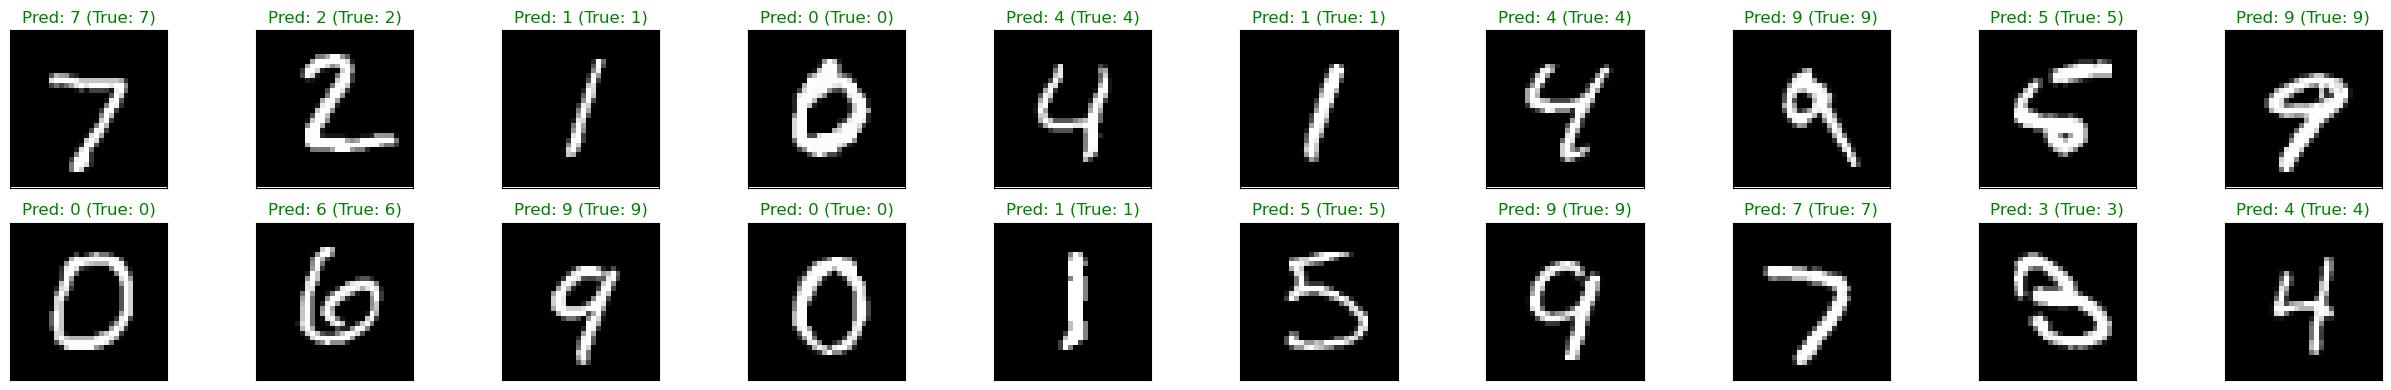

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move to device for prediction
images_device = images.to(device)
output = model(images_device)

# convert output probabilities to predicted class
_, preds = torch.max(output, 1)

# prep images for display (move back to cpu)
images = images.cpu().numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
num_images_to_show = 20

print("\nPrediction Visualization (Green = Correct, Red = Incorrect):")

for idx in range(num_images_to_show):
    ax = fig.add_subplot(2, int(num_images_to_show/2), idx+1, xticks=[], yticks=[])
    
    # Un-normalize the image for display: input = (input * std) + mean
    img_display = images[idx] * 0.3081 + 0.1307
    
    # Transpose format from (C, H, W) to (H, W, C) for Matplotlib
    plt.imshow(np.transpose(img_display, (1, 2, 0)), cmap='gray')
    
    # Set title color based on accuracy
    pred_label = preds[idx].item()
    true_label = labels[idx].item()
    color = 'green' if pred_label == true_label else 'red'
    
    ax.set_title(f"Pred: {pred_label} (True: {true_label})", color=color)

plt.tight_layout()
plt.show()


# Visualizing the errors

Visualizing the first 20 errors found:


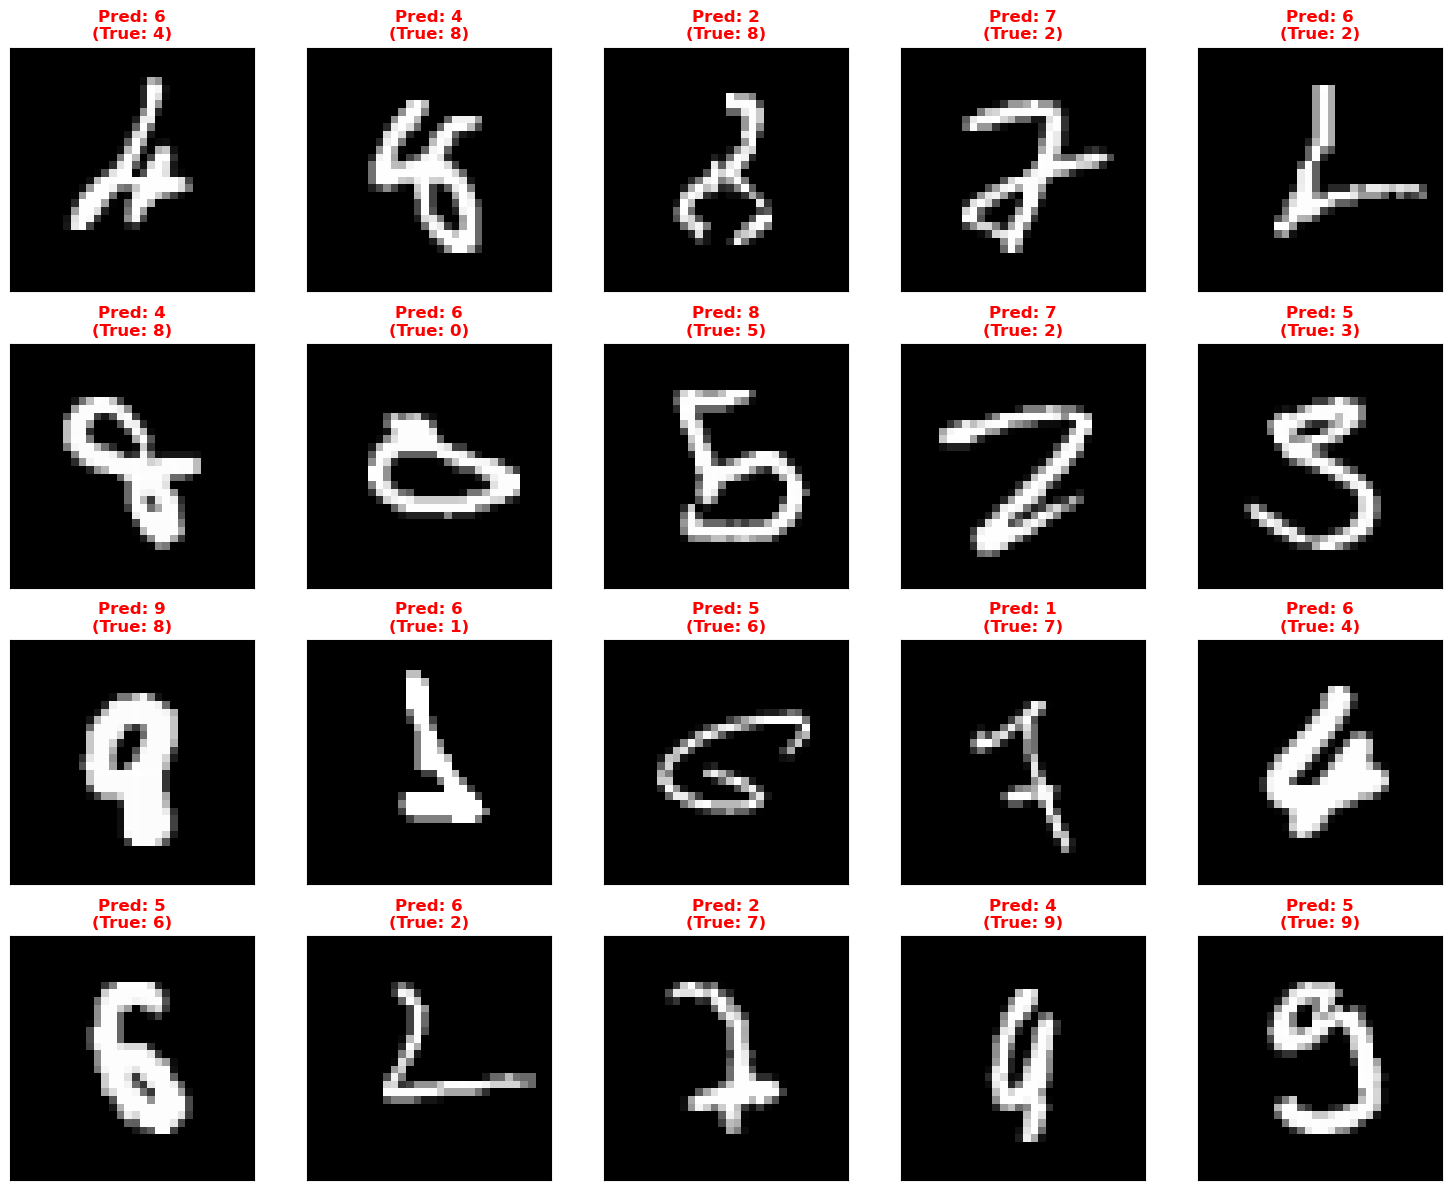

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_misclassified_images(model, test_loader, num_errors_to_show=20):
    """
    Finds and visualizes images where the model made incorrect predictions.
    """
    model.eval() # Set model to evaluation mode
    errors = []
    
    # 1. Collect errors
    with torch.no_grad():
        for images, labels in test_loader:
            # Move data to the configured device (GPU/CPU)
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            # Find indices where prediction does not match the actual label
            # .nonzero() returns indices of non-zero elements (where condition is True)
            error_indices = (predicted != labels).nonzero(as_tuple=False)
            
            # If there are errors in this batch
            if error_indices.nelement() > 0:
                 # Flatten indices for iteration
                 error_indices = error_indices.squeeze()
                 
                 # Handle edge case where there is only 1 error in the batch (0-d tensor)
                 if error_indices.ndim == 0:
                     error_indices = error_indices.unsqueeze(0)
                
                 for idx in error_indices:
                    idx = idx.item()
                    # Store tuple: (image, prediction, actual_label)
                    # We must move the image back to CPU for plotting with Matplotlib
                    errors.append((images[idx].cpu(), predicted[idx].item(), labels[idx].item()))
                    
                    if len(errors) >= num_errors_to_show:
                        break
            
            if len(errors) >= num_errors_to_show:
                break
    
    # 2. Plot the errors
    if len(errors) == 0:
        print("Amazing! The model did not make any errors in the checked samples.")
        return

    print(f"Visualizing the first {len(errors)} errors found:")
    
    # Configure dynamic grid layout
    cols = 5
    rows = (len(errors) // cols) + (1 if len(errors) % cols > 0 else 0)
    
    fig = plt.figure(figsize=(15, 3 * rows))
    
    for i, (img, pred, real) in enumerate(errors):
        ax = fig.add_subplot(rows, cols, i + 1, xticks=[], yticks=[])
        
        # Denormalize image for display: (img * std) + mean
        # MNIST specific stats: mean=0.1307, std=0.3081
        img = img * 0.3081 + 0.1307
        npimg = img.numpy()
        
        # Transpose from (C, H, W) to (H, W, C) for Matplotlib
        plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
        
        # Set title highlighting the error
        ax.set_title(f"Pred: {pred}\n(True: {real})", color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Execute the function
show_misclassified_images(model, test_loader)


# Saving the model

In [9]:
import os 
# Create "weights" directory if it doesn't exist
os.makedirs("weights", exist_ok=True)

# Set save path 
save_path = os.path.join("weights", "lenet5_mnist.pth")
torch.save(model.state_dict(), save_path)
print(f"Model saved as '{save_path}'")

Model saved as 'weights\lenet5_mnist.pth'
